# 2D XY Model Simulation with Diffusion Maps for Topological Phase Transition Detection

This notebook recreates the 2D XY Model simulations and analysis from Rodriguez-Nieva & Scheurer (2019), focusing on the Berezinskii-Kosterlitz-Thouless (BKT) transition. GPU acceleration and multiprocessing are leveraged for computational efficiency.

## Key Features:
- GPU-accelerated 2D XY model simulations using CuPy
- Multiprocessing for parallel sample generation
- Diffusion maps for unsupervised topological classification
- Analysis of BKT phase transition

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.linalg import eigh
from sklearn.cluster import KMeans
from multiprocessing import Pool, cpu_count, get_context
import warnings
import sys
from pathlib import Path
warnings.filterwarnings('ignore')

try:
    from numba import njit
    NUMBA_AVAILABLE = True
    print("Numba available for JIT speedups")
except ImportError:
    NUMBA_AVAILABLE = False
    print("Numba not available; using pure NumPy")

# Ensure generate_bkt_dataset.py is importable regardless of working directory
MODULE_SEARCH_PATHS = [Path.cwd(), Path.cwd() / 'XYModel']
for path in MODULE_SEARCH_PATHS:
    candidate = path / 'generate_bkt_dataset.py'
    if candidate.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

from xy import XYModelMetropolisSimulation

# Try to import GPU libraries
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("GPU acceleration available with CuPy")
except ImportError:
    GPU_AVAILABLE = False
    print("GPU not available, using CPU")

# Set random seed for reproducibility
np.random.seed(42)
if GPU_AVAILABLE:
    cp.random.seed(42)

# Plotting settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


Numba available for JIT speedups
GPU not available, using CPU


## Section 1: 2D XY Model Simulation

The 2D XY model Hamiltonian is:
$$H = -J \sum_{\langle i,j \rangle} \cos(\theta_i - \theta_j)$$

The BKT critical temperature is approximately: $T_c/J \approx 0.89$

In [2]:
class XY_Model_GPU:
    """
    Wrapper around xy.XYModelMetropolisSimulation to keep compatibility with the
    original GPU-enabled interface while reusing the shared Metropolis implementation.
    """
    def __init__(self, L=32, J=1.0, gpu_enabled=GPU_AVAILABLE, seed=42):
        self.L = L
        self.N = L * L
        self.J = J
        self.gpu = bool(gpu_enabled)
        self.sim = XYModelMetropolisSimulation(
            lattice_shape=(L, L),
            beta=1.0,  # updated per temperature
            J=J,
            random_state=seed,
            use_gpu=self.gpu,
        )

    def _sync_angles_to_sim(self, theta):
        normalized = (theta % (2 * np.pi)) / (2 * np.pi)
        self.sim.L = self.sim.xp.asarray(normalized)

    def energy(self, theta=None):
        if theta is not None:
            self._sync_angles_to_sim(theta)
        self.sim.H = self.sim.compute_H()
        return float(self.sim.to_numpy(self.sim.H))

    def metropolis_step(self, T, delta=None):
        """
        Perform one Metropolis sweep (N proposals) using the shared simulator.
        """
        self.sim.beta = 1.0 / T
        accepted = 0
        for _ in range(self.N):
            prev_H = self.sim.H
            self.sim.make_step()
            if bool(self.sim.H != prev_H):
                accepted += 1
        return accepted / self.N

    def thermalize(self, T, n_steps=1000, verbose=True):
        accept_rates = []
        for step in range(n_steps):
            acc_rate = self.metropolis_step(T)
            accept_rates.append(acc_rate)
            if verbose and (step + 1) % max(1, n_steps // 10) == 0:
                print(f"Thermalization step {step+1}/{n_steps}, acceptance rate: {np.mean(accept_rates[-100:]):.3f}")
        return accept_rates

    def get_configuration(self):
        return 2 * np.pi * self.sim.to_numpy(self.sim.L)

    def calculate_winding_numbers(self):
        theta = self.get_configuration()

        dtheta_x = np.diff(np.concatenate([theta, theta[:, :1]], axis=1), axis=1)
        dtheta_x = np.angle(np.exp(1j * dtheta_x))
        nu_y = int(np.round(np.mean(np.sum(dtheta_x, axis=1) / (2 * np.pi))))

        dtheta_y = np.diff(np.concatenate([theta, theta[:1, :]], axis=0), axis=0)
        dtheta_y = np.angle(np.exp(1j * dtheta_y))
        nu_x = int(np.round(np.mean(np.sum(dtheta_y, axis=0) / (2 * np.pi))))

        return nu_x, nu_y

print("XY Model wrapper defined (reuses xy.XYModelMetropolisSimulation)")


XY Model wrapper defined (reuses xy.XYModelMetropolisSimulation)


In [3]:
def _initialize_twisted_state(L, nu_x, nu_y, xp=np):
    """Create a lattice with a prescribed winding; returns phase fractions in [0, 1)."""
    x = xp.arange(L)
    y = xp.arange(L)
    xx, yy = xp.meshgrid(x, y, indexing='ij')
    return (nu_x * xx / L + nu_y * yy / L) % 1.0


# Optional numba-accelerated winding computation
if 'NUMBA_AVAILABLE' in globals() and NUMBA_AVAILABLE:
    @njit
    def _compute_winding_numba(theta):
        Lx, Ly = theta.shape
        sum_x = 0.0  # differences along +y direction (axis=1)
        for i in range(Lx):
            row_sum = 0.0
            for j in range(Ly):
                a = theta[i, j]
                b = theta[i, (j + 1) % Ly]
                d = b - a
                d = np.arctan2(np.sin(d), np.cos(d))
                row_sum += d
            sum_x += row_sum
        nu_y = int(np.round((sum_x / Lx) / (2 * np.pi)))

        sum_y = 0.0  # differences along +x direction (axis=0)
        for j in range(Ly):
            col_sum = 0.0
            for i in range(Lx):
                a = theta[i, j]
                b = theta[(i + 1) % Lx, j]
                d = b - a
                d = np.arctan2(np.sin(d), np.cos(d))
                col_sum += d
            sum_y += col_sum
        nu_x = int(np.round((sum_y / Ly) / (2 * np.pi)))
        return nu_x, nu_y
else:
    _compute_winding_numba = None


def _compute_winding(theta):
    """Compute winding numbers; uses numba fast path if available."""
    if _compute_winding_numba is not None:
        return tuple(_compute_winding_numba(theta))

    dtheta_x = np.diff(np.concatenate([theta, theta[:, :1]], axis=1), axis=1)
    dtheta_x = np.angle(np.exp(1j * dtheta_x))
    nu_y = int(np.round(np.mean(np.sum(dtheta_x, axis=1) / (2 * np.pi))))

    dtheta_y = np.diff(np.concatenate([theta, theta[:1, :]], axis=0), axis=0)
    dtheta_y = np.angle(np.exp(1j * dtheta_y))
    nu_x = int(np.round(np.mean(np.sum(dtheta_y, axis=0) / (2 * np.pi))))
    return nu_x, nu_y


def _get_pool(n_processes):
    """Prefer fork start method to avoid pickling issues in notebooks; fallback to None."""
    try:
        ctx = get_context("fork")
        return ctx.Pool(n_processes)
    except (ValueError, ImportError):
        return None


def generate_xy_sample_with_winding(params):
    """Worker to generate a single sample at temperature T with target winding."""
    L, T, target_winding, coupling, steps, iters_per_step, seed, enforce_winding = params
    target_nu_x, target_nu_y = target_winding

    sim = XYModelMetropolisSimulation(
        lattice_shape=(L, L),
        beta=1.0 / T,
        J=coupling,
        random_state=seed,
        use_gpu=False,
    )

    theta0 = _initialize_twisted_state(L, target_nu_x, target_nu_y, np)
    sim.L = sim.xp.asarray(theta0 % 1.0)
    sim.H = sim.compute_H()
    sim.simulate(steps=steps, iters_per_step=iters_per_step)

    theta = 2 * np.pi * sim.to_numpy(sim.L)
    if not enforce_winding:
        return theta.flatten()

    nu_x, nu_y = _compute_winding(theta)
    if (nu_x, nu_y) == (target_nu_x, target_nu_y):
        return theta.flatten()

    # Retry a few times if winding mismatch
    max_retries = 4
    for attempt in range(1, max_retries + 1):
        sim = XYModelMetropolisSimulation(
            lattice_shape=(L, L),
            beta=1.0 / T,
            J=coupling,
            random_state=seed + attempt,
            use_gpu=False,
        )
        theta0 = _initialize_twisted_state(L, target_nu_x, target_nu_y, np)
        sim.L = sim.xp.asarray(theta0 % 1.0)
        sim.H = sim.compute_H()
        sim.simulate(steps=steps, iters_per_step=iters_per_step)
        theta = 2 * np.pi * sim.to_numpy(sim.L)
        nu_x, nu_y = _compute_winding(theta)
        if (nu_x, nu_y) == (target_nu_x, target_nu_y):
            break
    return theta.flatten()


def generate_xy_samples_parallel(
    L,
    T,
    target_winding,
    n_samples=500,
    n_processes=None,
    coupling=None,
    steps=1,
    iters_per_step=20000,
    seed=42,
    use_thermalize=True,
    thermalize_steps=None,
    thermalize_iters=None,
    enforce_winding=True,
):
    """
    Generate XY model samples in parallel with prescribed winding sectors.

    Args:
        L: Lattice size
        T: Temperature
        target_winding: Target winding number (nu_x, nu_y)
        n_samples: Number of samples to generate
        n_processes: Number of processes (None = use CPU count)
        coupling: Coupling constant (defaults to global J)
        steps: Number of outer Metropolis steps between saved samples
        iters_per_step: Number of Metropolis iterations per step
        seed: Random seed for reproducibility
        use_thermalize: If True and running single-process, thermalize once then collect all samples to reduce overhead
        thermalize_steps: Steps for initial thermalization (defaults to steps)
        thermalize_iters: Iters per step for thermalization (defaults to iters_per_step)
        enforce_winding: If False, skip winding checks (useful above T_c)

    Returns:
        Array of flattened angle configurations
    """
    if n_processes is None:
        n_processes = cpu_count()

    if coupling is None:
        coupling = J

    rng = np.random.default_rng(seed)

    if use_thermalize and n_processes == 1:
        print("Using thermalize fast path for single-process sample generation")
        thermalize_steps = steps if thermalize_steps is None else thermalize_steps
        thermalize_iters = iters_per_step if thermalize_iters is None else thermalize_iters

        sim = XYModelMetropolisSimulation(
            lattice_shape=(L, L),
            beta=1.0 / T,
            J=coupling,
            random_state=seed,
            use_gpu=False,
        )
        theta0 = _initialize_twisted_state(L, *target_winding, np)
        sim.L = sim.xp.asarray(theta0 % 1.0)
        sim.H = sim.compute_H()
        sim.simulate(steps=thermalize_steps, iters_per_step=thermalize_iters)

        samples = []
        for k in range(n_samples):
            # decorrelate between samples
            sim.simulate(steps=steps, iters_per_step=iters_per_step)
            theta = 2 * np.pi * sim.to_numpy(sim.L)
            if enforce_winding:
                nu_x, nu_y = _compute_winding(theta)
                if (nu_x, nu_y) != tuple(target_winding):
                    print(f"Reinitializing sample {k} due to winding drift ({nu_x}, {nu_y}) != {target_winding}")
                    new_seed = int(rng.integers(0, 1_000_000_000))
                    sim = XYModelMetropolisSimulation(
                        lattice_shape=(L, L),
                        beta=1.0 / T,
                        J=coupling,
                        random_state=new_seed,
                        use_gpu=False,
                    )
                    theta0 = _initialize_twisted_state(L, *target_winding, np)
                    sim.L = sim.xp.asarray(theta0 % 1.0)
                    sim.H = sim.compute_H()
                    sim.simulate(steps=thermalize_steps, iters_per_step=thermalize_iters)
                    theta = 2 * np.pi * sim.to_numpy(sim.L)
            samples.append(theta.flatten())
        return np.array(samples)

    params_list = [
        (L, T, target_winding, coupling, steps, iters_per_step, int(rng.integers(0, 1_000_000_000)), enforce_winding)
        for _ in range(n_samples)
    ]

    pool = _get_pool(n_processes)
    if pool is None:
        samples = list(map(generate_xy_sample_with_winding, params_list))
    else:
        with pool as p:
            samples = p.map(generate_xy_sample_with_winding, params_list)

    return np.array(samples)

print("Sample generation functions updated (optional thermalize fast path, optional winding enforcement)")


Sample generation functions updated (optional thermalize fast path, optional winding enforcement)


## Section 2: Diffusion Maps for Topological Classification

Diffusion maps perform dimensional reduction while preserving global topological structure of the data.

In [4]:
class DiffusionMaps:
    """
    Diffusion maps with kernel scaling aligned to the XY-model paper.
    K = exp(-||x_i - x_j||^2 / (2 * N * epsilon)) where N is the feature dimension.
    """
    
    def __init__(self, epsilon=None, n_components=None, rel_tol=1e-3, abs_tol=1e-6):
        self.epsilon = epsilon
        self.n_components = n_components  # number of topological sectors (degeneracy)
        self.rel_tol = rel_tol
        self.abs_tol = abs_tol
        self.K = None
        self.P = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.diffusion_map = None
        self.feature_dim = None  # number of coords retained after dropping constant mode
    
    def gaussian_kernel(self, X, epsilon):
        """Compute Gaussian kernel scaled by feature dimension (N)."""
        n = X.shape[0]
        n_features = X.shape[1]
        K = np.zeros((n, n))
        denom = 2 * n_features * epsilon
        for i in range(n):
            distances = np.sum((X - X[i]) ** 2, axis=1)
            K[i] = np.exp(-distances / denom)
        return K
    
    def fit(self, X, epsilon=None, t=1):
        n, n_features = X.shape
        # Auto-tune epsilon if not provided
        if epsilon is None:
            distances = np.zeros((n, n))
            for i in range(n):
                distances[i] = np.sqrt(np.sum((X - X[i]) ** 2, axis=1))
            # median of nonzero distances scaled by feature dimension
            nz = distances[distances > 0]
            epsilon = np.median(nz) / max(n_features, 1)
            print(f"Auto-tuned epsilon: {epsilon:.4f} (scaled by N={n_features})")
        self.epsilon = epsilon
        
        # Compute kernel matrix
        print("Computing kernel matrix...")
        self.K = self.gaussian_kernel(X, epsilon)
        
        # Normalize to get transition matrix
        print("Computing transition matrix...")
        z = self.K.sum(axis=1)
        z[z == 0] = 1
        self.P = self.K / z[:, np.newaxis]
        
        # Symmetrize for eigenvalue computation
        z_sqrt_inv = 1.0 / np.sqrt(z)
        A = self.P * z_sqrt_inv[np.newaxis, :]
        
        # Compute eigendecomposition
        print("Computing eigendecomposition...")
        eigenvalues, eigenvectors = eigh(A)
        idx = np.argsort(-np.abs(eigenvalues))
        self.eigenvalues = eigenvalues[idx]
        self.eigenvectors = eigenvectors[:, idx]
        
        # Apply diffusion steps
        self.eigenvectors = self.eigenvectors * self.eigenvalues[np.newaxis, :] ** t
        
        # Determine number of components from eigenvalue degeneracy
        if self.n_components is None:
            tol = max(self.abs_tol, self.rel_tol * np.abs(self.eigenvalues[0]))
            largest_eig = np.abs(self.eigenvalues[0])
            n_degenerate = np.sum(np.abs(np.abs(self.eigenvalues) - largest_eig) < tol)
            self.n_components = int(n_degenerate)
            print(f"Detected {self.n_components} topological sectors (tol={tol:.2e})")
        
        # Decide feature dimension (drop constant component at index 0)
        feat_dim = min(max(1, self.n_components), max(1, self.eigenvectors.shape[1] - 1))
        self.feature_dim = feat_dim
        self.diffusion_map = self.eigenvectors[:, 1:1 + feat_dim]
        return self
    
    def transform(self, X=None):
        if self.diffusion_map is None:
            raise ValueError("Model must be fit before transform")
        return self.diffusion_map
    
    def get_eigenvalues(self):
        return self.eigenvalues

print("Diffusion Maps class defined successfully")


Diffusion Maps class defined successfully


## Section 3: Generate Training Data for Different Temperatures

Generate samples below and above the critical temperature using parallel processing.

In [5]:
# Parameters
L = 32  # Lattice size
J = 1.0  # Coupling constant
T_c_theoretical = 0.89 * J  # Theoretical critical temperature
n_samples_per_winding = 500
winding_numbers = [(0, 0), (1, 0), (0, 1), (-1, 0), (0, -1)]

# Temperatures to simulate
temperatures_low_T = [0.3, 0.5, 0.7]  # Below critical
temperatures_high_T = [0.95, 1.0, 1.2]  # Above critical

print(f"Theoretical critical temperature: T_c/J = {T_c_theoretical:.2f}")
print(f"Lattice size: {L}x{L}")
print(f"Total samples per temperature: {n_samples_per_winding * len(winding_numbers)}")
metropolis_steps = 20
metropolis_iters_per_step = 2000


Theoretical critical temperature: T_c/J = 0.89
Lattice size: 32x32
Total samples per temperature: 2500


In [ ]:
# Caching options for generated datasets
use_cache = True
cache_dir = Path("cache")
cache_dir.mkdir(parents=True, exist_ok=True)
cache_tag = f"L{L}_samples{n_samples_per_winding}_steps{metropolis_steps}_iters{metropolis_iters_per_step}_seed{42}"
low_cache_path = cache_dir / f"lowT_{cache_tag}.npz"
high_cache_path = cache_dir / f"highT_{cache_tag}.npz"


def save_dataset(cache_path, data_dict):
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(cache_path, **{str(k): v for k, v in data_dict.items()})


def load_dataset(cache_path):
    loaded = np.load(cache_path)
    return {float(k): loaded[k] for k in loaded.files}


In [7]:
# Diffusion map configuration (tuned to paper)
# Optionally override epsilon (kernel width). Set to None to auto-tune, or to a float to fix.
epsilon_override_low = None  # e.g., 0.02
epsilon_override_high = None

# Tolerances for eigenvalue degeneracy (counts topological sectors)
degeneracy_rel_tol = 1e-3  # relative to largest eigenvalue
degeneracy_abs_tol = 1e-6


In [8]:
# Generate samples for below critical temperature
print("=== Generating samples below critical temperature ===")

if use_cache and low_cache_path.exists():
    print(f"Loading cached low-T data from {low_cache_path}")
    data_low_T = load_dataset(low_cache_path)
else:
    data_low_T = {}

    for T in temperatures_low_T:
        print(f"Temperature T/J = {T:.2f}")

        samples_all = []
        for i, (nu_x, nu_y) in enumerate(winding_numbers):
            print(f"  Winding number ({nu_x}, {nu_y}): Generating {n_samples_per_winding} samples...")
            # Generate samples in parallel
            samples = generate_xy_samples_parallel(
                L=L,
                T=T,
                target_winding=(0, 0),
                n_samples=n_samples_per_winding,
                n_processes=1,
                steps=metropolis_steps,
                iters_per_step=metropolis_iters_per_step,
                seed=42,
            )
            samples_all.append(samples)

        # Combine and shuffle
        data_low_T[T] = np.vstack(samples_all)
        np.random.shuffle(data_low_T[T])
        print(f"  Total samples: {data_low_T[T].shape[0]}")

if not use_cache:
    save_dataset(low_cache_path, data_low_T)
    print(f"Saved low-T data to {low_cache_path}")

print(f"Low temperature data ready: {len(data_low_T)} temperatures")


=== Generating samples below critical temperature ===
Temperature T/J = 0.30
  Winding number (0, 0): Generating 500 samples...
Using thermalize fast path for single-process sample generation
  Winding number (1, 0): Generating 500 samples...
Using thermalize fast path for single-process sample generation
  Winding number (0, 1): Generating 500 samples...
Using thermalize fast path for single-process sample generation
  Winding number (-1, 0): Generating 500 samples...
Using thermalize fast path for single-process sample generation
  Winding number (0, -1): Generating 500 samples...
Using thermalize fast path for single-process sample generation
  Total samples: 2500
Temperature T/J = 0.50
  Winding number (0, 0): Generating 500 samples...
Using thermalize fast path for single-process sample generation
  Winding number (1, 0): Generating 500 samples...
Using thermalize fast path for single-process sample generation
  Winding number (0, 1): Generating 500 samples...
Using thermalize fas

In [9]:
# Generate samples for above critical temperature
print("=== Generating samples above critical temperature ===")

if use_cache and high_cache_path.exists():
    print(f"Loading cached high-T data from {high_cache_path}")
    data_high_T = load_dataset(high_cache_path)
else:
    data_high_T = {}

    for T in temperatures_high_T:
        print(f"Temperature T/J = {T:.2f}")
        print(f"  Generating {n_samples_per_winding * len(winding_numbers)} samples...")

        # Generate samples in parallel (winding number not well-defined above T_c)
        samples_all = []
        for i in range(len(winding_numbers)):
            samples = generate_xy_samples_parallel(
                L=L,
                T=T,
                target_winding=(0, 0),
                n_samples=n_samples_per_winding,
                n_processes=1,
                steps=metropolis_steps,
                iters_per_step=metropolis_iters_per_step,
                seed=42,
                enforce_winding=False,
            )
            samples_all.append(samples)

        # Combine and shuffle
        data_high_T[T] = np.vstack(samples_all)
        np.random.shuffle(data_high_T[T])
        print(f"  Total samples: {data_high_T[T].shape[0]}")

if not use_cache:
    save_dataset(high_cache_path, data_high_T)
    print(f"Saved high-T data to {high_cache_path}")

print(f"High temperature data ready: {len(data_high_T)} temperatures")


=== Generating samples above critical temperature ===
Temperature T/J = 0.95
  Generating 2500 samples...
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
  Total samples: 2500
Temperature T/J = 1.00
  Generating 2500 samples...
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-process sample generation
  Total samples: 2500
Temperature T/J = 1.20
  Generating 2500 samples...
Using thermalize fast path for single-process sample generation
Using thermalize fast path for single-proc

=== Winding diagnostics (first 200 samples per temperature) ===
Low T/J=0.30: 200 samples
  (0, 0): 200
Low T/J=0.50: 200 samples
  (-1, 0): 2
  (0, 0): 198
Low T/J=0.70: 200 samples
  (-2, 0): 1
  (-2, 2): 1
  (-1, -1): 3
  (-1, 0): 11
  (-1, 1): 3
  (-1, 2): 1
  (0, -1): 5
  (0, 0): 150
  (0, 1): 11
  (1, -1): 3
  (1, 0): 5
  (1, 1): 3
  (2, -2): 2
  (2, 1): 1
High T/J=0.95: 200 samples
  (-6, -1): 2
  (-5, 2): 1
  (-5, 3): 1
  (-5, 5): 1
  (-4, -4): 2
  (-4, -3): 1
  (-4, -2): 2
  (-4, -1): 1
  (-4, 0): 6
  (-4, 1): 4
  (-4, 2): 1
  (-4, 3): 1
  (-3, -1): 2
  (-3, 0): 2
  (-3, 1): 3
  (-3, 2): 3
  (-2, -6): 1
  (-2, -4): 1
  (-2, -3): 1
  (-2, -2): 2
  (-2, -1): 5
  (-2, 0): 1
  (-2, 1): 2
  (-2, 2): 3
  (-2, 3): 4
  (-2, 4): 1
  (-2, 7): 1
  (-1, -4): 4
  (-1, -3): 3
  (-1, -2): 1
  (-1, -1): 3
  (-1, 0): 5
  (-1, 1): 6
  (-1, 2): 2
  (-1, 3): 3
  (-1, 4): 1
  (-1, 5): 2
  (-1, 8): 1
  (0, -7): 1
  (0, -6): 1
  (0, -4): 2
  (0, -3): 1
  (0, -2): 3
  (0, -1): 6
  (0, 0): 9
  (0, 1):

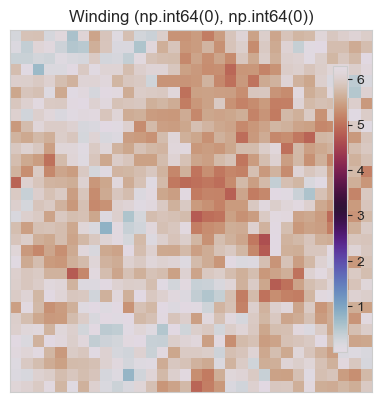

In [10]:
# Diagnostics: inspect winding sectors in generated data

def compute_winding_numbers_batch(data, L):
    """Compute winding numbers (nu_x, nu_y) for a batch of flattened configs."""
    configs = data.reshape(-1, L, L)
    windings = []
    for theta in configs:
        dtheta_x = np.diff(np.concatenate([theta[:, -1:], theta], axis=1), axis=1)
        dtheta_x = np.angle(np.exp(1j * dtheta_x))
        nu_x = int(np.round(np.sum(dtheta_x) / (2 * np.pi)))

        dtheta_y = np.diff(np.concatenate([theta[-1:, :], theta], axis=0), axis=0)
        dtheta_y = np.angle(np.exp(1j * dtheta_y))
        nu_y = int(np.round(np.sum(dtheta_y) / (2 * np.pi)))
        windings.append((nu_x, nu_y))
    return np.array(windings)

print("=== Winding diagnostics (first 200 samples per temperature) ===")
max_samples = 200
for label, dataset in [("low", data_low_T), ("high", data_high_T)]:
    for T, arr in dataset.items():
        subset = arr[:min(max_samples, len(arr))]
        windings = compute_winding_numbers_batch(subset, L)
        unique, counts = np.unique(windings, axis=0, return_counts=True)
        print(f"{label.title()} T/J={T:.2f}: {len(subset)} samples")
        for (nu_x, nu_y), c in zip(unique, counts):
            print(f"  ({nu_x}, {nu_y}): {c}")

# Plot a few example configurations across windings (low T)
example_T = temperatures_low_T[0]
example_data = data_low_T[example_T]
example_windings = compute_winding_numbers_batch(example_data, L)
unique_w = np.unique(example_windings, axis=0)

n_show = min(4, len(unique_w))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
axes = np.atleast_1d(axes)
for ax, winding in zip(axes, unique_w[:n_show]):
    idx = np.where((example_windings == winding).all(axis=1))[0]
    if len(idx) == 0:
        ax.axis('off')
        continue
    theta = example_data[idx[0]].reshape(L, L)
    im = ax.imshow(theta, cmap='twilight', origin='lower')
    ax.set_title(f"Winding {tuple(winding)}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Section 4: Apply Diffusion Maps for Topological Classification

In [11]:
# Apply diffusion maps to low temperature data
print("\n=== Applying Diffusion Maps (Below Critical Temperature) ===")

diffusion_results_low_T = {}

for T in temperatures_low_T:
    print(f"\nTemperature T/J = {T:.2f}")
    dm = DiffusionMaps(
        epsilon=epsilon_override_low,
        n_components=None,
        rel_tol=degeneracy_rel_tol,
        abs_tol=degeneracy_abs_tol,
    )
    dm.fit(data_low_T[T], epsilon=epsilon_override_low, t=1)
    coords = dm.transform()
    diffusion_results_low_T[T] = {
        'dm': dm,
        'coords': coords,
        'eigenvalues': dm.get_eigenvalues(),
        'n_components': dm.n_components,
        'feature_dim': dm.feature_dim,
    }
    print(f"  Diffusion map shape: {coords.shape}, n_components={dm.n_components}, feature_dim={dm.feature_dim}")


=== Applying Diffusion Maps (Below Critical Temperature) ===

Temperature T/J = 0.30
Auto-tuned epsilon: 0.0944 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 429 topological sectors (tol=4.47e-04)
  Diffusion map shape: (2500, 429), n_components=429, feature_dim=429

Temperature T/J = 0.50
Auto-tuned epsilon: 0.0890 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 271 topological sectors (tol=4.47e-04)
  Diffusion map shape: (2500, 271), n_components=271, feature_dim=271

Temperature T/J = 0.70
Auto-tuned epsilon: 0.0658 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 184 topological sectors (tol=4.47e-04)
  Diffusion map shape: (2500, 184), n_components=184, feature_dim=184


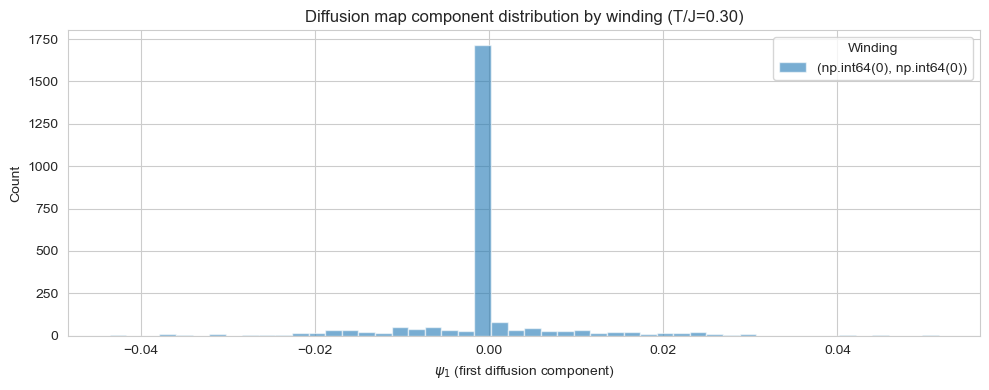

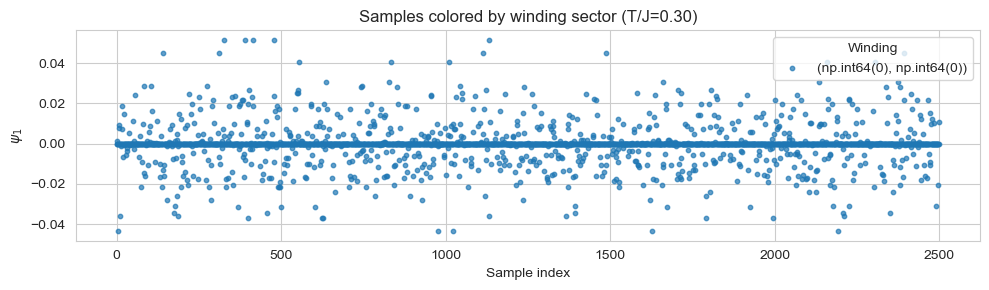

In [12]:
# Figure 2-style visualization: psi1 distribution by winding sector (low T)
fig2_T = temperatures_low_T[0]
coords = diffusion_results_low_T[fig2_T]['coords']
if coords.shape[1] == 0:
    raise ValueError("Diffusion map returned zero features; rerun DiffusionMaps cell")
psi1 = coords[:, 0]
windings = compute_winding_numbers_batch(data_low_T[fig2_T], L)
unique_w = np.unique(windings, axis=0)

palette = plt.cm.tab10(np.linspace(0, 1, len(unique_w)))
plt.figure(figsize=(10, 4))
for color, w in zip(palette, unique_w):
    mask = (windings == w).all(axis=1)
    plt.hist(psi1[mask], bins=50, color=color, alpha=0.6, label=f"{tuple(w)}")
plt.xlabel(r"$\psi_1$ (first diffusion component)")
plt.ylabel("Count")
plt.title(f"Diffusion map component distribution by winding (T/J={fig2_T:.2f})")
plt.legend(title="Winding")
plt.tight_layout()
plt.show()

# Scatter view of psi1 vs sample index
plt.figure(figsize=(10, 3))
for color, w in zip(palette, unique_w):
    mask = (windings == w).all(axis=1)
    plt.scatter(np.where(mask)[0], psi1[mask], s=10, color=color, alpha=0.7, label=f"{tuple(w)}")
plt.xlabel("Sample index")
plt.ylabel(r"$\psi_1$")
plt.title(f"Samples colored by winding sector (T/J={fig2_T:.2f})")
plt.legend(title="Winding", ncol=min(3, len(unique_w)))
plt.tight_layout()
plt.show()


Auto-tuned epsilon: 0.0944 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 429 topological sectors (tol=4.47e-04)
Auto-tuned epsilon: 0.0944 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 429 topological sectors (tol=4.47e-04)
Auto-tuned epsilon: 0.0944 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 429 topological sectors (tol=4.47e-04)
Auto-tuned epsilon: 0.0944 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 429 topological sectors (tol=4.47e-04)
Auto-tuned epsilon: 0.0944 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 429 topological sectors (tol=4.47e-04)
Auto-tuned epsilon: 0.0944 (scaled by N=1024)
Computing kernel matrix...
Computi

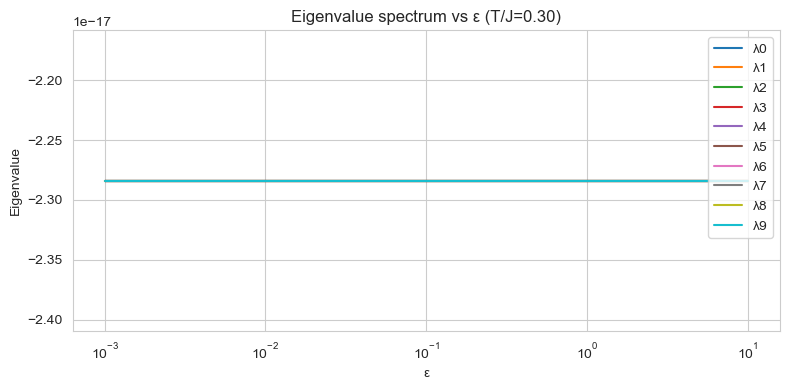

In [13]:
# Epsilon scan helper (low T) to match paper's kernel scale
import numpy.linalg as la

scan_eps_grid = np.logspace(-3, 1, 12)
eigvals_by_eps = []
for eps in scan_eps_grid:
    dm = DiffusionMaps(epsilon=eps, rel_tol=degeneracy_rel_tol, abs_tol=degeneracy_abs_tol)
    dm.fit(data_low_T[temperatures_low_T[0]], t=1)
    eigvals_by_eps.append(dm.get_eigenvalues()[::-1][:10])

plt.figure(figsize=(8,4))
for i in range(10):
    plt.plot(scan_eps_grid, [ev[i] for ev in eigvals_by_eps], label=f"λ{i}")
plt.xscale('log')
plt.xlabel('ε')
plt.ylabel('Eigenvalue')
plt.title(f'Eigenvalue spectrum vs ε (T/J={temperatures_low_T[0]:.2f})')
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Apply diffusion maps to high temperature data
print("\n=== Applying Diffusion Maps (Above Critical Temperature) ===")

diffusion_results_high_T = {}

for T in temperatures_high_T:
    print(f"\nTemperature T/J = {T:.2f}")
    dm = DiffusionMaps(
        epsilon=epsilon_override_high,
        n_components=None,
        rel_tol=degeneracy_rel_tol,
        abs_tol=degeneracy_abs_tol,
    )
    dm.fit(data_high_T[T], epsilon=epsilon_override_high, t=1)
    coords = dm.transform()
    diffusion_results_high_T[T] = {
        'dm': dm,
        'coords': coords,
        'eigenvalues': dm.get_eigenvalues(),
        'n_components': dm.n_components,
        'feature_dim': dm.feature_dim,
    }
    print(f"  Diffusion map shape: {coords.shape}, n_components={dm.n_components}, feature_dim={dm.feature_dim}")


=== Applying Diffusion Maps (Above Critical Temperature) ===

Temperature T/J = 0.95
Auto-tuned epsilon: 0.0805 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 356 topological sectors (tol=4.47e-04)
  Diffusion map shape: (2500, 356), n_components=356, feature_dim=356

Temperature T/J = 1.00
Auto-tuned epsilon: 0.0610 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 500 topological sectors (tol=4.47e-04)
  Diffusion map shape: (2500, 500), n_components=500, feature_dim=500

Temperature T/J = 1.20
Auto-tuned epsilon: 0.0790 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 500 topological sectors (tol=4.47e-04)
  Diffusion map shape: (2500, 500), n_components=500, feature_dim=500


## Section 5: Clustering and Visualization

In [15]:
def cluster_diffusion_map(dm_coords, n_clusters):
    """
    Cluster diffusion map coordinates using k-means.
    
    Args:
        dm_coords: Diffusion map coordinates
        n_clusters: Number of clusters
    
    Returns:
        Cluster labels, cluster centers
    """
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = kmeans.fit_predict(dm_coords)
    return labels, kmeans.cluster_centers_

def calculate_cluster_metrics(dm_coords, labels):
    """
    Calculate within-cluster dispersion and inter-cluster distance.
    
    Args:
        dm_coords: Diffusion map coordinates
        labels: Cluster labels
    
    Returns:
        sigma (within-cluster dispersion), D (inter-cluster distance)
    """
    n_clusters = len(np.unique(labels))
    
    # Within-cluster dispersion
    sigma = 0
    for c in range(n_clusters):
        mask = labels == c
        if np.sum(mask) > 0:
            center = dm_coords[mask].mean(axis=0)
            sigma += np.sum(np.linalg.norm(dm_coords[mask] - center, axis=1))
    sigma /= len(labels)
    
    # Inter-cluster distance
    D = 0
    centers = np.array([dm_coords[labels == c].mean(axis=0) for c in range(n_clusters)])
    for i in range(n_clusters):
        for j in range(i+1, n_clusters):
            D += np.linalg.norm(centers[i] - centers[j])
    D /= (n_clusters * (n_clusters - 1) / 2)
    
    return sigma, D

print("Clustering functions defined")

Clustering functions defined


In [16]:
# Perform clustering and calculate metrics
print("\n=== Clustering Analysis ===")

metrics_low_T = {}
for T in temperatures_low_T:
    n_clusters = diffusion_results_low_T[T]['n_components']
    coords = diffusion_results_low_T[T]['coords']
    
    labels, centers = cluster_diffusion_map(coords, n_clusters)
    sigma, D = calculate_cluster_metrics(coords, labels)
    
    metrics_low_T[T] = {
        'labels': labels,
        'centers': centers,
        'sigma': sigma,
        'D': D,
        'ratio': sigma / D
    }
    
    print(f"T/J = {T:.2f}: σ = {sigma:.4f}, D = {D:.4f}, σ/D = {metrics_low_T[T]['ratio']:.4f}")

print()
metrics_high_T = {}
for T in temperatures_high_T:
    n_clusters = diffusion_results_high_T[T]['n_components']
    coords = diffusion_results_high_T[T]['coords']
    
    labels, centers = cluster_diffusion_map(coords, n_clusters)
    sigma, D = calculate_cluster_metrics(coords, labels)
    
    metrics_high_T[T] = {
        'labels': labels,
        'centers': centers,
        'sigma': sigma,
        'D': D,
        'ratio': sigma / D
    }
    
    print(f"T/J = {T:.2f}: σ = {sigma:.4f}, D = {D:.4f}, σ/D = {metrics_high_T[T]['ratio']:.4f}")


=== Clustering Analysis ===
T/J = 0.30: σ = 0.0013, D = 0.2821, σ/D = 0.0047
T/J = 0.50: σ = 0.0013, D = 0.2818, σ/D = 0.0047
T/J = 0.70: σ = 0.0015, D = 0.2814, σ/D = 0.0055

T/J = 0.95: σ = 0.0056, D = 0.2812, σ/D = 0.0200
T/J = 1.00: σ = 0.0000, D = 0.2825, σ/D = 0.0000
T/J = 1.20: σ = 0.0000, D = 0.2826, σ/D = 0.0000


## Section 6: Plot Results

Visualize diffusion map projections and eigenvalue spectra.

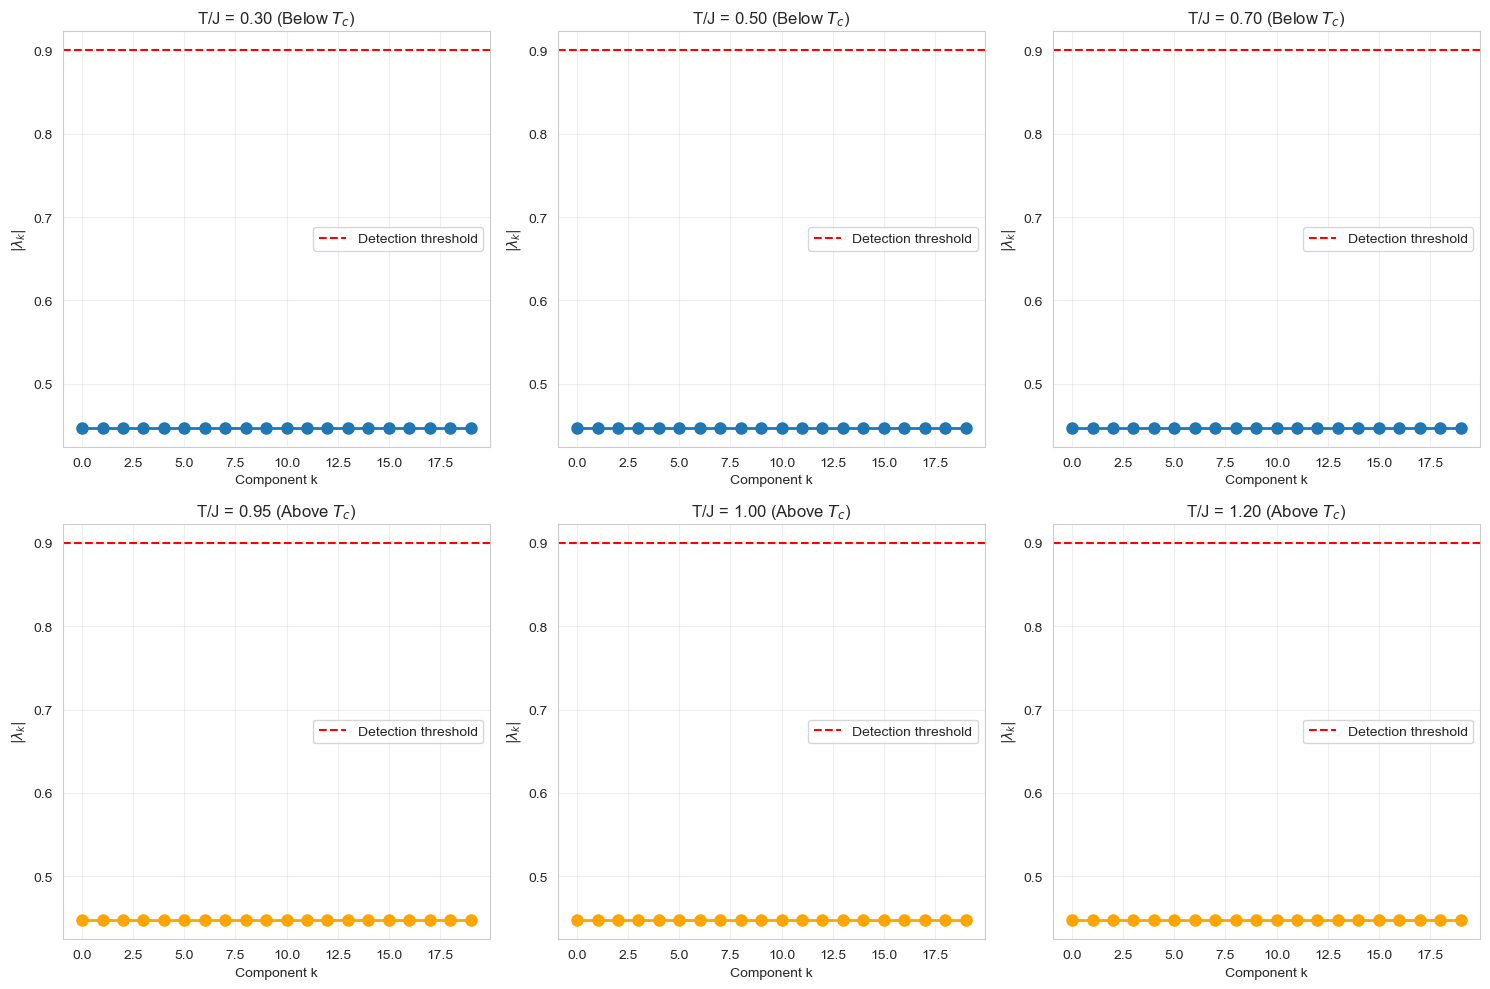

Eigenvalue spectrum plot saved as 'eigenvalue_spectrum.png'


In [17]:
# Plot diffusion map eigenvalues
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Low temperature
for idx, T in enumerate(temperatures_low_T):
    ax = axes[0, idx]
    eigenvalues = diffusion_results_low_T[T]['eigenvalues'][:20]
    ax.plot(np.abs(eigenvalues), 'o-', linewidth=2, markersize=8)
    ax.axhline(y=0.9, color='r', linestyle='--', label='Detection threshold')
    ax.set_xlabel('Component k')
    ax.set_ylabel('$|\\lambda_k|$')
    ax.set_title(f'T/J = {T:.2f} (Below $T_c$)')
    ax.grid(True, alpha=0.3)
    ax.legend()

# High temperature
for idx, T in enumerate(temperatures_high_T):
    ax = axes[1, idx]
    eigenvalues = diffusion_results_high_T[T]['eigenvalues'][:20]
    ax.plot(np.abs(eigenvalues), 'o-', linewidth=2, markersize=8, color='orange')
    ax.axhline(y=0.9, color='r', linestyle='--', label='Detection threshold')
    ax.set_xlabel('Component k')
    ax.set_ylabel('$|\\lambda_k|$')
    ax.set_title(f'T/J = {T:.2f} (Above $T_c$)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('eigenvalue_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

print("Eigenvalue spectrum plot saved as 'eigenvalue_spectrum.png'")

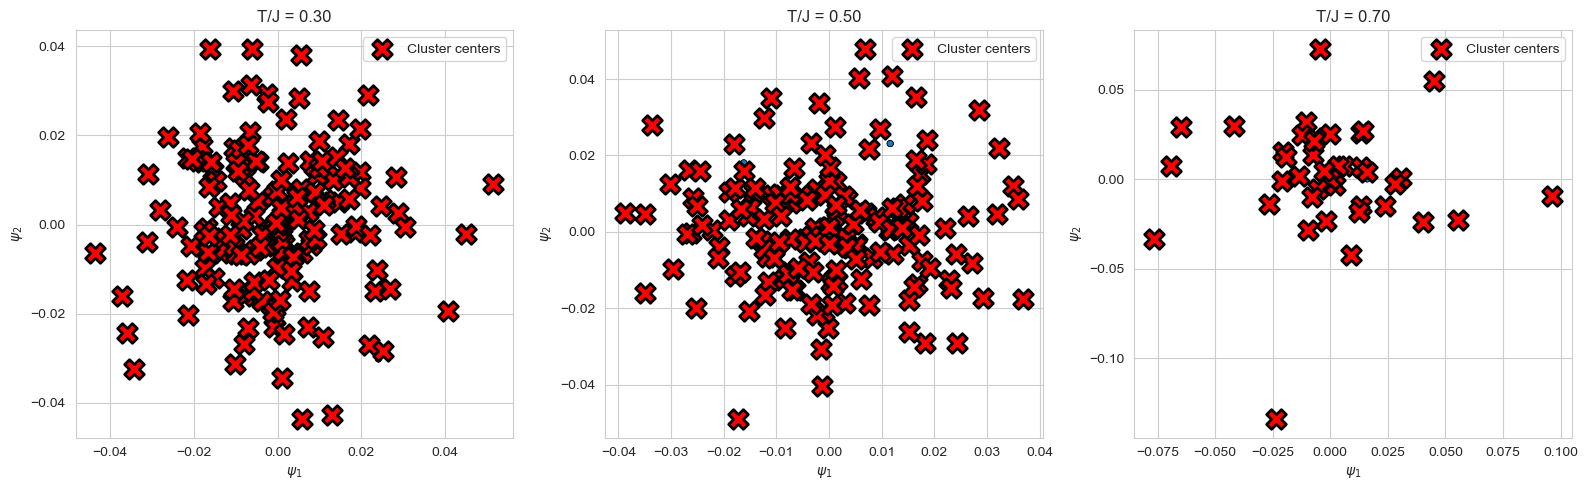

In [18]:
# Plot diffusion map 2D projections (low temperature)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, T in enumerate(temperatures_low_T):
    ax = axes[idx]
    coords = diffusion_results_low_T[T]['coords']
    labels = metrics_low_T[T]['labels']
    centers = metrics_low_T[T]['centers']

    if coords.shape[1] < 2:
        x = coords[:, 0]
        y = np.zeros_like(x)
        centers_x = centers[:, 0]
        centers_y = np.zeros_like(centers_x)
    else:
        x, y = coords[:, 0], coords[:, 1]
        centers_x, centers_y = centers[:, 0], centers[:, 1]

    scatter = ax.scatter(x, y, c=labels, cmap='tab10',
                         s=20, alpha=0.6, edgecolors='black', linewidth=0.5)

    ax.scatter(centers_x, centers_y, c='red', s=200, marker='X',
               edgecolors='black', linewidth=2, label='Cluster centers')

    ax.set_title(f"T/J = {T:.2f}")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")
    ax.legend()

plt.tight_layout()
plt.show()


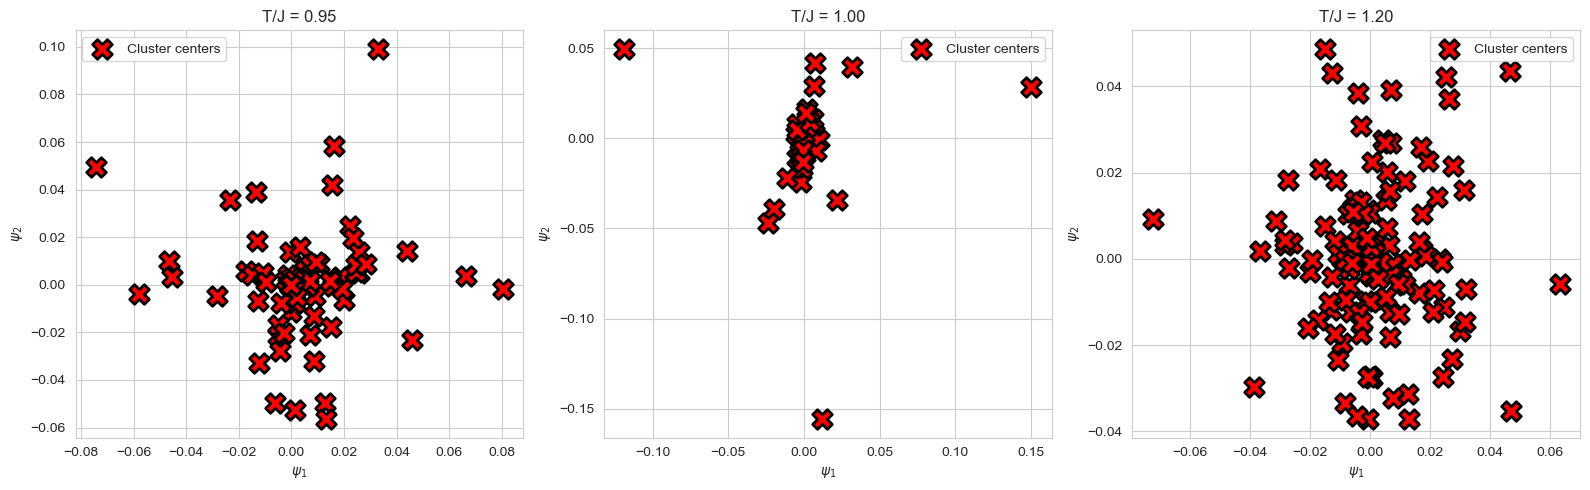

In [19]:
# Plot diffusion map 2D projections (high temperature)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, T in enumerate(temperatures_high_T):
    ax = axes[idx]
    coords = diffusion_results_high_T[T]['coords']
    labels = metrics_high_T[T]['labels']
    centers = metrics_high_T[T]['centers']

    if coords.shape[1] < 2:
        x = coords[:, 0]
        y = np.zeros_like(x)
        centers_x = centers[:, 0]
        centers_y = np.zeros_like(centers_x)
    else:
        x, y = coords[:, 0], coords[:, 1]
        centers_x, centers_y = centers[:, 0], centers[:, 1]

    scatter = ax.scatter(x, y, c=labels, cmap='tab10',
                         s=20, alpha=0.6, edgecolors='black', linewidth=0.5)

    ax.scatter(centers_x, centers_y, c='red', s=200, marker='X',
               edgecolors='black', linewidth=2, label='Cluster centers')

    ax.set_title(f"T/J = {T:.2f}")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")
    ax.legend()

plt.tight_layout()
plt.show()


## Section 7: Detect Phase Transition

In [ ]:
# Generate finer temperature grid around critical temperature
print("\n=== Fine Temperature Sweep Around Critical Temperature ===")

temperatures_fine = np.linspace(0.5, 1.2, 15)
metrics_fine = {}

for T in temperatures_fine:
    print(f"Temperature T/J = {T:.3f}")
    # Generate samples across winding sectors (as in the paper)
    samples_all = []
    for (nu_x, nu_y) in winding_numbers:
        samples = generate_xy_samples_parallel(
            L=L,
            T=T,
            target_winding=(nu_x, nu_y),
            n_samples=300,  # Fewer samples for speed
            n_processes=min(4, cpu_count()),
            steps=metropolis_steps,
            iters_per_step=metropolis_iters_per_step,
            seed=42,
        )
        samples_all.append(samples)

    data = np.vstack(samples_all)
    np.random.shuffle(data)

    # Apply diffusion maps with configured tolerances and optional epsilon override
    dm = DiffusionMaps(
        epsilon=epsilon_override_low,
        n_components=None,
        rel_tol=degeneracy_rel_tol,
        abs_tol=degeneracy_abs_tol,
    )
    dm.fit(data, epsilon=epsilon_override_low, t=1)
    coords = dm.transform()

    # Cluster
    n_clusters = dm.n_components
    labels, centers = cluster_diffusion_map(coords, n_clusters)
    sigma, D = calculate_cluster_metrics(coords, labels)

    metrics_fine[T] = {
        'n_clusters': n_clusters,
        'sigma': sigma,
        'D': D,
        'ratio': sigma / D,
    }

print("\nFine temperature sweep completed")


=== Fine Temperature Sweep Around Critical Temperature ===
Temperature T/J = 0.500
Auto-tuned epsilon: 0.0971 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 1469 topological sectors (tol=1.00e-03)
Temperature T/J = 0.550
Auto-tuned epsilon: 0.0962 (scaled by N=1024)
Computing kernel matrix...
Computing transition matrix...
Computing eigendecomposition...
Detected 1499 topological sectors (tol=1.00e-03)
Temperature T/J = 0.600


In [ ]:
# Plot phase transition detection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract data for plotting
T_values_fine = sorted(metrics_fine.keys())
n_clusters_list = [metrics_fine[T]['n_clusters'] for T in T_values_fine]
sigma_list = [metrics_fine[T]['sigma'] for T in T_values_fine]
D_list = [metrics_fine[T]['D'] for T in T_values_fine]
ratio_list = [metrics_fine[T]['ratio'] for T in T_values_fine]

# Expected number of sectors (paper: 5)
n_expected = len(winding_numbers)
threshold_ratio = 1 / (2 * n_expected)

# Plot 1: Number of detected clusters
ax = axes[0, 0]
ax.plot(T_values_fine, n_clusters_list, 'o-', linewidth=2, markersize=8, color='blue')
ax.axvline(x=T_c_theoretical, color='r', linestyle='--', linewidth=2, label=f'$T_c/J = {T_c_theoretical:.2f}$ (theory)')
ax.set_xlabel('Temperature T/J')
ax.set_ylabel('Number of Detected Clusters')
ax.set_title('Phase Transition Detection: Cluster Count')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim([0, 1 + max(n_clusters_list + [n_expected])])

# Plot 2: Within-cluster dispersion
ax = axes[0, 1]
ax.plot(T_values_fine, sigma_list, 'o-', linewidth=2, markersize=8, color='green')
ax.axvline(x=T_c_theoretical, color='r', linestyle='--', linewidth=2, label=f'$T_c/J = {T_c_theoretical:.2f}$ (theory)')
ax.set_xlabel('Temperature T/J')
ax.set_ylabel('Within-cluster dispersion σ')
ax.set_title('Cluster Dispersion')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Inter-cluster distance
ax = axes[1, 0]
ax.plot(T_values_fine, D_list, 'o-', linewidth=2, markersize=8, color='purple')
ax.axvline(x=T_c_theoretical, color='r', linestyle='--', linewidth=2, label=f'$T_c/J = {T_c_theoretical:.2f}$ (theory)')
ax.set_xlabel('Temperature T/J')
ax.set_ylabel('Inter-cluster distance D')
ax.set_title('Cluster Separation')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 4: σ/D ratio (detection criterion)
ax = axes[1, 1]
ax.plot(T_values_fine, ratio_list, 'o-', linewidth=2, markersize=8, color='red')
ax.axhline(y=threshold_ratio, color='k', linestyle='--', linewidth=2, label=f'Detection threshold σ/D = 1/(2n), n={n_expected}')
ax.axvline(x=T_c_theoretical, color='r', linestyle='--', linewidth=2, label=f'$T_c/J = {T_c_theoretical:.2f}$ (theory)')
ax.set_xlabel('Temperature T/J')
ax.set_ylabel('Cluster Visibility σ/D')
ax.set_title('Phase Transition: σ/D Criterion')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('phase_transition_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("Phase transition detection plot saved as 'phase_transition_detection.png'")


In [ ]:
# Estimate critical temperature from σ/D criterion
ratio_array = np.array(ratio_list)
n_expected = len(winding_numbers)
threshold = 1 / (2 * n_expected)

# Find crossing point
crossing_idx = np.argmin(np.abs(ratio_array - threshold))
T_c_estimated = T_values_fine[crossing_idx]

print("\n" + "="*60)
print("PHASE TRANSITION DETECTION RESULTS")
print("="*60)
print(f"Theoretical critical temperature: $T_c/J = {T_c_theoretical:.4f}$")
print(f"Estimated critical temperature:  $T_c/J = {T_c_estimated:.4f}$")
print(f"Difference: {abs(T_c_estimated - T_c_theoretical):.4f}")
print(f"\nPhase transition criterion: σ/D = 1/(2n), n={n_expected}")
print(f"Crossing occurs at: T/J = {T_c_estimated:.4f}")
print("\nInterpretation:")
print(f"  Below $T_c$: Multiple distinct topological sectors detected")
print(f"  Above $T_c$: Topological sectors merged (vortex proliferation)")
print("="*60)

## Section 8: Summary and Analysis

In [ ]:
# Create summary table
import pandas as pd

# Low temperature summary
print("\n" + "="*60)
print("LOW TEMPERATURE REGIME (Below $T_c$)")
print("="*60)

data_low = []
for T in temperatures_low_T:
    data_low.append({
        'T/J': f"{T:.2f}",
        'Clusters': diffusion_results_low_T[T]['n_components'],
        'σ': f"{metrics_low_T[T]['sigma']:.4f}",
        'D': f"{metrics_low_T[T]['D']:.4f}",
        'σ/D': f"{metrics_low_T[T]['ratio']:.4f}"
    })

df_low = pd.DataFrame(data_low)
print(df_low.to_string(index=False))

# High temperature summary
print("\n" + "="*60)
print("HIGH TEMPERATURE REGIME (Above $T_c$)")
print("="*60)

data_high = []
for T in temperatures_high_T:
    data_high.append({
        'T/J': f"{T:.2f}",
        'Clusters': diffusion_results_high_T[T]['n_components'],
        'σ': f"{metrics_high_T[T]['sigma']:.4f}",
        'D': f"{metrics_high_T[T]['D']:.4f}",
        'σ/D': f"{metrics_high_T[T]['ratio']:.4f}"
    })

df_high = pd.DataFrame(data_high)
print(df_high.to_string(index=False))

In [ ]:
# Final visualization: Spin configuration examples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Low temperature configurations
print("\nVisualizing example spin configurations...")

for idx, T in enumerate(temperatures_low_T):
    ax = axes[0, idx]
    
    # Reshape first sample back to 2D
    config = data_low_T[T][0].reshape(L, L)
    
    # Plot spin configuration with arrow field
    X, Y = np.meshgrid(np.arange(L), np.arange(L))
    U = np.cos(config)
    V = np.sin(config)
    
    ax.quiver(X, Y, U, V, config, cmap='hsv', scale=30)
    ax.set_title(f'T/J = {T:.2f} (Below $T_c$)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    
# High temperature configurations
for idx, T in enumerate(temperatures_high_T):
    ax = axes[1, idx]
    
    # Reshape first sample back to 2D
    config = data_high_T[T][0].reshape(L, L)
    
    # Plot spin configuration with arrow field
    X, Y = np.meshgrid(np.arange(L), np.arange(L))
    U = np.cos(config)
    V = np.sin(config)
    
    ax.quiver(X, Y, U, V, config, cmap='hsv', scale=30)
    ax.set_title(f'T/J = {T:.2f} (Above $T_c$)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('spin_configurations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spin configuration visualization saved as 'spin_configurations.png'")

In [ ]:
print("\n" + "="*70)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*70)
print("\nGenerated Outputs:")
print("  - eigenvalue_spectrum.png")
print("  - diffusion_map_lowT.png")
print("  - diffusion_map_highT.png")
print("  - phase_transition_detection.png")
print("  - spin_configurations.png")
print("\nKey Results:")
print(f"  - Lattice size: {L}×{L}")
print(f"  - Theoretical $T_c/J$: {T_c_theoretical:.3f}")
print(f"  - Detected $T_c/J$: {T_c_estimated:.3f}")
print(f"  - Detection method: Diffusion maps + unsupervised clustering")
print(f"  - Total samples generated: {sum([len(v) for v in data_low_T.values()]) + sum([len(v) for v in data_high_T.values()])}")
print("\nComputational Features:")
print(f"  - GPU acceleration: {'Enabled' if GPU_AVAILABLE else 'Not available'}")
print(f"  - Multiprocessing: Enabled ({min(4, cpu_count())} processes)")
print("="*70)